# Weather research: all-data exploratory analysis

**Status:** current, general-purpose data audit notebook.

This notebook explores everything currently pulled into `data/`: raw API
responses and shards, processed research tables, calibration datasets,
exports, model artifacts, and temporary pull outputs. It is read-only by
default and is designed to remain usable as the local data lake grows.

The workflow has two levels:

1. inventory **every file** and summarize coverage, size, freshness, and
   possible duplicates;
2. load the important consolidated tables and sample one representative
   file from each raw/calibration family for schema inspection.

Run from top to bottom. Change the configuration in the next cell when a
deeper or faster pass is needed.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import re
import shutil
import sqlite3
import subprocess
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing pyproject.toml and data/")

ROOT = find_repo_root()
DATA = ROOT / "data"

# Safe defaults for interactive use. Inventory still covers every file.
MAX_ROWS_PER_TABLE = 250_000
SCHEMA_SAMPLE_ROWS = 500
MAX_SCHEMA_FAMILIES = None  # set an integer for an even faster schema pass
DEEP_FILE_METADATA = False  # True adds exact size/freshness but is slow during active backfills
HASH_DUPLICATE_CANDIDATES = False  # full hashes can be expensive on very large files
ACTIVE_TABLE = "processed/model_errors.csv"
RANDOM_SEED = 42

print(f"Repository: {ROOT}")
print(f"Data root:  {DATA}")

Repository: D:\dev\weather-research
Data root:  D:\dev\weather-research\data


## 1. Complete artifact inventory

This scan reads filesystem metadata only, so all files are represented
without loading their contents. `logical_family` collapses daily shards
into source-level groups while retaining separate calibration experiments.

In [2]:
def logical_family(relative_path: str) -> str:
    parts = Path(relative_path).parts
    if not parts:
        return "unknown"
    if parts[0] in {"raw", "calibration"} and len(parts) >= 2:
        return "/".join(parts[:2])
    if parts[0] == "tmp" and len(parts) >= 2:
        return "/".join(parts[:2])
    return parts[0]

def scan_paths(folder: Path) -> list[Path]:
    # ripgrep's directory walker is much faster on this shard-heavy tree.
    if shutil.which("rg"):
        result = subprocess.run(["rg", "--files", str(folder)], check=True,
                                capture_output=True, text=True)
        return [Path(line) for line in result.stdout.splitlines() if line]
    return [Path(dp) / name for dp, _, names in os.walk(folder) for name in names]

records = []
for path in scan_paths(DATA):
    stat = path.stat() if DEEP_FILE_METADATA else None
    rel = path.relative_to(DATA).as_posix()
    records.append({
        "relative_path": rel,
        "logical_family": logical_family(rel),
        "top_level": Path(rel).parts[0],
        "extension": path.suffix.lower() or "[none]",
        "size_bytes": stat.st_size if stat else np.nan,
        "size_mb": stat.st_size / 2**20 if stat else np.nan,
        "modified_utc": pd.Timestamp(stat.st_mtime, unit="s", tz="UTC") if stat else pd.NaT,
        "name": path.name,
        "path": path,
    })

files = pd.DataFrame(records).sort_values("relative_path").reset_index(drop=True)
assert not files.empty, f"No files found under {DATA}"

overview = pd.DataFrame({
    "metric": ["files", "directories represented", "total size (GB)", "newest modification (UTC)"],
    "value": [len(files), files["path"].map(lambda p: p.parent).nunique(),
              round(files["size_bytes"].sum(min_count=1) / 2**30, 3), files["modified_utc"].max()],
})
display(overview)
display(files.drop(columns="path").sort_values("size_bytes", ascending=False).head(25))

,metric,value
0,files,13421
1,directories represented,521
2,total size (GB),NaN
3,newest modification (UTC),NaT


,relative_path,logical_family,top_level,extension,size_bytes,size_mb,modified_utc,name
0,calibration/backtests/station_stacking_v11_2026_ridge_stack_backtest.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v11_2026_ridge_stack_backtest.csv
1,calibration/backtests/station_stacking_v11_2026_ridge_stack_backtest.predictions.jsonl,calibration/backtests,calibration,.jsonl,NaN,NaN,NaT,station_stacking_v11_2026_ridge_stack_backtest.predictions.jsonl
2,calibration/backtests/station_stacking_v11_2026_ridge_stack_backtest_costcap_70_80_summary.json,calibration/backtests,calibration,.json,NaN,NaN,NaT,station_stacking_v11_2026_ridge_stack_backtest_costcap_70_80_summary.json
3,calibration/backtests/station_stacking_v11_2026_ridge_stack_backtest_metrics.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v11_2026_ridge_stack_backtest_metrics.csv
4,calibration/backtests/station_stacking_v6_2026_oof_wide.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v6_2026_oof_wide.csv
5,calibration/backtests/station_stacking_v6_v7_predictions_long.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v6_v7_predictions_long.csv
6,calibration/backtests/station_stacking_v7_2026_oof_method_metrics.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v7_2026_oof_method_metrics.csv
7,calibration/backtests/station_stacking_v7_2026_oof_selected_best_by_station.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v7_2026_oof_selected_best_by_station.csv
8,calibration/backtests/station_stacking_v7_2026_oof_wide.csv,calibration/backtests,calibration,.csv,NaN,NaN,NaT,station_stacking_v7_2026_oof_wide.csv
9,calibration/backup_before_16test_20260618_073834/sdk_11am_live_safe_2021_2026/sdk_nwp_0h_cache.csv,calibration/backup_before_16test_20260618_073834,calibration,.csv,NaN,NaN,NaT,sdk_nwp_0h_cache.csv


,top_level,files,size_gb,newest_utc
0,calibration,4045,NaN,NaT
1,calibration_strict,4,NaN,NaT
2,exports,4,NaN,NaT
3,processed,22,NaN,NaT
4,raw,9337,NaN,NaT
5,tmp,9,NaN,NaT


,extension,files,size_gb
0,.csv,8467,NaN
2,.json,4775,NaN
5,.sqlite3,91,NaN
1,.joblib,81,NaN
3,.jsonl,6,NaN
4,.md,1,NaN


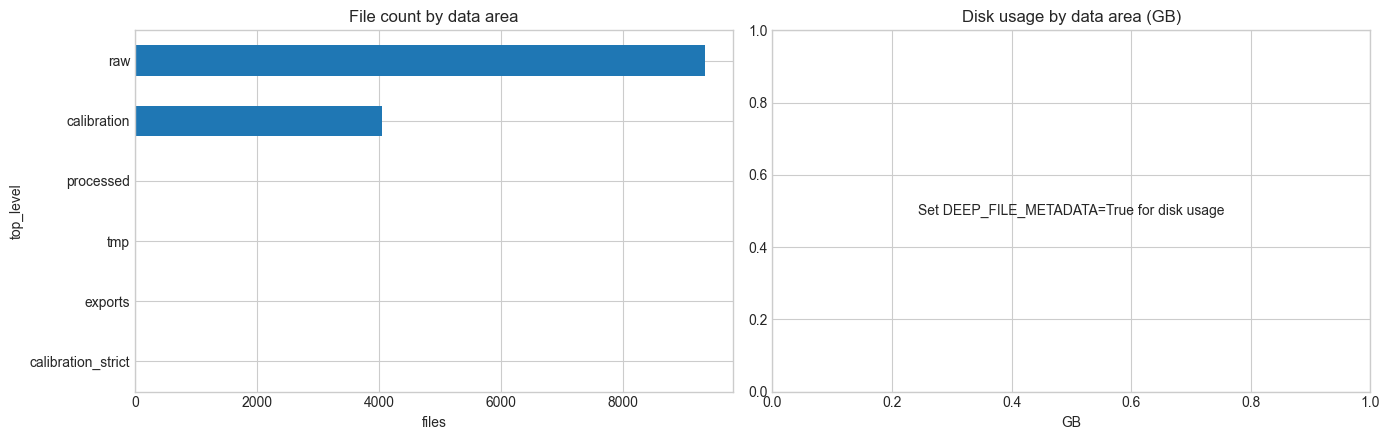

In [3]:
by_area = (files.groupby("top_level", as_index=False)
           .agg(files=("relative_path", "size"), size_gb=("size_bytes", lambda s: s.sum(min_count=1) / 2**30),
                newest_utc=("modified_utc", "max"))
           .sort_values("size_gb", ascending=False))
by_format = (files.groupby("extension", as_index=False)
             .agg(files=("relative_path", "size"), size_gb=("size_bytes", lambda s: s.sum(min_count=1) / 2**30))
             .sort_values("files", ascending=False))
display(by_area)
display(by_format)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_area.set_index("top_level")["files"].sort_values().plot.barh(ax=axes[0], title="File count by data area")
if by_area["size_gb"].notna().any():
    by_area.set_index("top_level")["size_gb"].sort_values().plot.barh(ax=axes[1], title="Disk usage by data area (GB)")
else:
    axes[1].text(.5, .5, "Set DEEP_FILE_METADATA=True for disk usage", ha="center", va="center")
    axes[1].set_title("Disk usage by data area (GB)")
axes[0].set_xlabel("files")
axes[1].set_xlabel("GB")
plt.tight_layout()
plt.show()

## 2. Coverage, freshness, and duplicate candidates

The filename parser surfaces station codes and ISO dates wherever they
occur, which makes shard coverage visible even before opening the files.
Duplicate candidates are conservative: same basename and size. Optional
full SHA-256 verification is available for candidate groups.

,logical_family,station_hint,files,first_date,last_date,size_mb
0,calibration/v11_settlement_enriched_v1,KATL,729,2021-01-01,2024-03-01,0.0
1,calibration/v11_settlement_enriched_v1,KDAL,730,2021-01-01,2024-03-02,0.0
2,raw/actuals,KATL,876,2022-01-01,2026-06-15,0.0
3,raw/actuals,KAUS,399,2022-01-01,2026-05-20,0.0
4,raw/actuals,KBKF,4,2026-05-01,2026-05-02,0.0
5,raw/actuals,KDAL,407,2022-01-01,2026-05-20,0.0
6,raw/actuals,KDCA,2,2025-01-20,2025-01-20,0.0
7,raw/actuals,KHOU,284,2022-01-01,2026-05-02,0.0
8,raw/actuals,KLAX,342,2022-01-01,2026-05-02,0.0
9,raw/actuals,KLGA,615,2022-01-01,2026-05-03,0.0


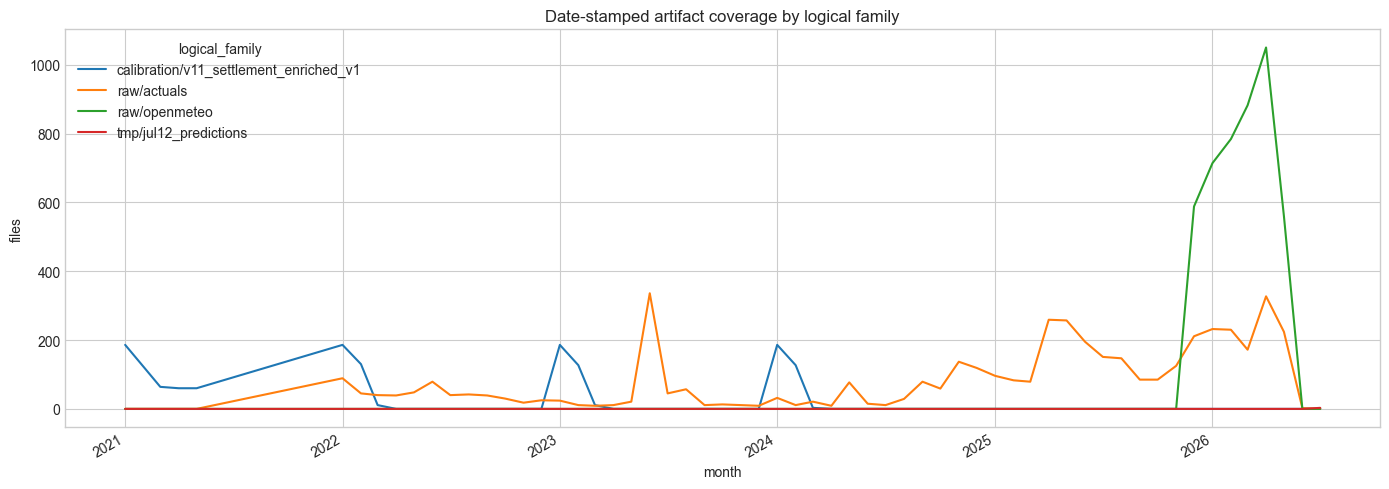

In [4]:
station_pattern = re.compile(r"(?<![A-Z0-9])([KC][A-Z]{3})(?![A-Z0-9])", re.I)
date_pattern = re.compile(r"(20\d{2}-\d{2}-\d{2})")

files["station_hint"] = files["relative_path"].str.extract(station_pattern, expand=False).str.upper()
files["date_hint"] = pd.to_datetime(files["relative_path"].str.extract(date_pattern, expand=False), errors="coerce")
pull_coverage = (files.dropna(subset=["date_hint"])
                 .groupby(["logical_family", "station_hint"], dropna=False)
                 .agg(files=("relative_path", "size"), first_date=("date_hint", "min"),
                      last_date=("date_hint", "max"), size_mb=("size_mb", "sum"))
                 .reset_index().sort_values(["logical_family", "station_hint"], na_position="last"))
display(pull_coverage.head(100))

monthly_pulls = (files.dropna(subset=["date_hint"])
                 .assign(month=lambda x: x["date_hint"].dt.to_period("M").dt.to_timestamp())
                 .groupby(["month", "logical_family"]).size().unstack(fill_value=0))
if not monthly_pulls.empty:
    monthly_pulls.plot(figsize=(14, 5), title="Date-stamped artifact coverage by logical family")
    plt.ylabel("files")
    plt.tight_layout()
    plt.show()

In [5]:
backup_mask = files["relative_path"].str.contains(
    r"before_|backup|copy|smoke|probe|tmp|\.bak", case=False, regex=True
)
backup_summary = (files.loc[backup_mask]
                  .groupby("logical_family", as_index=False)
                  .agg(candidate_files=("relative_path", "size"), size_mb=("size_mb", "sum"))
                  .sort_values("size_mb", ascending=False))
duplicate_candidates = (files.dropna(subset=["size_bytes"]).groupby(["name", "size_bytes"], as_index=False)
                        .agg(copies=("relative_path", "size"), paths=("relative_path", list))
                        .query("copies > 1").sort_values(["copies", "size_bytes"], ascending=False))
display(backup_summary.head(30))
display(duplicate_candidates.head(30))

if HASH_DUPLICATE_CANDIDATES and not duplicate_candidates.empty:
    candidate_paths = {p for paths in duplicate_candidates["paths"] for p in paths}
    def sha256(rel: str) -> str:
        digest = hashlib.sha256()
        with (DATA / rel).open("rb") as handle:
            for chunk in iter(lambda: handle.read(2**20), b""):
                digest.update(chunk)
        return digest.hexdigest()
    verified_hashes = pd.DataFrame({"relative_path": sorted(candidate_paths)})
    verified_hashes["sha256"] = verified_hashes["relative_path"].map(sha256)
    display(verified_hashes.groupby("sha256").filter(lambda g: len(g) > 1).sort_values("sha256"))

,logical_family,candidate_files,size_mb
0,calibration/backup_before_16test_20260618_073834,27,0.0
1,calibration/direct_nbm_13z_live_safe_smoke,2,0.0
2,calibration/direct_nbm_smoke,2,0.0
3,calibration/direct_nbm_smoke_all,2,0.0
4,calibration/nbm_rap_features_shards_parse_probe,1,0.0
5,calibration/nbm_rap_features_shards_smoke_script2,1,0.0
6,calibration/nbm_rap_features_shards_smoke_script3,1,0.0
7,calibration/nbm_rap_features_smoke,1,0.0
8,calibration/nbm_rap_features_smoke2,1,0.0
9,calibration/nbm_rap_features_smoke3,1,0.0


,name,size_bytes,copies,paths


## 3. Representative schema pass across all data families

One representative CSV/JSON/JSONL/SQLite file is inspected from every
logical family. This finds broken or surprising schemas without opening
thousands of daily shards. The complete file inventory above remains the
source of truth for file-level coverage.

In [6]:
def read_sample(path: Path, nrows: int = SCHEMA_SAMPLE_ROWS) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path, nrows=nrows, low_memory=False)
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True, nrows=nrows)
    if suffix == ".json":
        with path.open("r", encoding="utf-8", errors="replace") as handle:
            payload = json.load(handle)
        if isinstance(payload, list):
            return pd.json_normalize(payload[:nrows])
        if isinstance(payload, dict):
            for value in payload.values():
                if isinstance(value, list):
                    return pd.json_normalize(value[:nrows])
            return pd.json_normalize(payload)
    if suffix == ".sqlite3":
        with sqlite3.connect(path) as conn:
            tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)["name"].tolist()
            if tables:
                safe_name = tables[0].replace('"', '""')
                return pd.read_sql(f'SELECT * FROM "{safe_name}" LIMIT {int(nrows)}', conn)
    raise ValueError(f"Unsupported tabular format: {path.suffix}")

schema_files = files[files["extension"].isin([".csv", ".json", ".jsonl", ".sqlite3"])].copy()
# Prefer the smallest nonempty representative. In particular, JSON row
# limits cannot be applied until after decoding the document.
representatives = (schema_files
                   .sort_values("size_bytes", ascending=True, na_position="last")
                   .drop_duplicates("logical_family"))
if MAX_SCHEMA_FAMILIES is not None:
    representatives = representatives.head(MAX_SCHEMA_FAMILIES)

schema_records = []
schema_samples = {}
for row in representatives.itertuples(index=False):
    try:
        sample = read_sample(row.path)
        schema_samples[row.logical_family] = sample
        schema_records.append({
            "logical_family": row.logical_family, "representative": row.relative_path,
            "sample_rows": len(sample), "columns": sample.shape[1],
            "numeric_columns": sample.select_dtypes(include=np.number).shape[1],
            "sample_missing_pct": round(sample.isna().mean().mean() * 100, 2), "status": "ok",
        })
    except Exception as exc:
        schema_records.append({
            "logical_family": row.logical_family, "representative": row.relative_path,
            "sample_rows": np.nan, "columns": np.nan, "numeric_columns": np.nan,
            "sample_missing_pct": np.nan, "status": f"{type(exc).__name__}: {exc}",
        })
schema_catalog = pd.DataFrame(schema_records).sort_values("logical_family")
display(schema_catalog)

,logical_family,representative,sample_rows,columns,numeric_columns,sample_missing_pct,status
0,calibration/backtests,calibration/backtests/station_stacking_v11_2026_ridge_stack_backtest.csv,500.0,11.0,5.0,0.00,ok
1,calibration/backup_before_16test_20260618_073834,calibration/backup_before_16test_20260618_073834/sdk_11am_live_safe_2021_2026/sdk_nwp_0h_cache.csv,72.0,53.0,33.0,45.28,ok
2,calibration/baseline_results.csv,calibration/baseline_results.csv,500.0,21.0,15.0,3.48,ok
3,calibration/calibration_samples.csv,calibration/calibration_samples.csv,500.0,50.0,35.0,6.64,ok
4,calibration/direct_nbm_13z_live_safe_jul12,calibration/direct_nbm_13z_live_safe_jul12/direct_nbm_0h_cache.csv,2.0,23.0,6.0,4.35,ok
...,...,...,...,...,...,...,...
379,raw/actuals,raw/actuals/iem_asos_1min_KATL_2022-01-01.csv,500.0,4.0,0.0,0.00,ok
380,raw/openmeteo,raw/openmeteo/openmeteo_KATL_2025-12-05_0.json,1.0,23.0,5.0,0.00,ok
381,raw/polymarket,raw/polymarket/events_07ad5502ec97c4c9.json,100.0,46.0,3.0,0.20,ok
382,tmp/jul12_predictions,tmp/jul12_predictions/gfs/gfs_v11_mostlyright_2026-07-12.jsonl,2.0,15.0,2.0,0.00,ok


## 4. Consolidated analysis-table catalog

These are the compact, analysis-ready tables: all top-level CSVs from
`processed`, `outputs`, `exports`, `calibration_strict`, plus the root of
`calibration`. Large tables are capped by `MAX_ROWS_PER_TABLE`; the
catalog clearly marks capped loads.

In [7]:
def discover_analysis_tables() -> list[Path]:
    paths = []
    for area in ["processed", "outputs", "exports", "calibration_strict"]:
        folder = DATA / area
        if folder.exists():
            paths.extend(folder.glob("*.csv"))
    calibration = DATA / "calibration"
    if calibration.exists():
        paths.extend(calibration.glob("*.csv"))
    return sorted(set(paths))

def count_csv_rows(path: Path) -> int:
    with path.open("rb") as handle:
        return max(sum(chunk.count(b"\n") for chunk in iter(lambda: handle.read(2**20), b"")) - 1, 0)

tables = {}
table_records = []
for path in discover_analysis_tables():
    key = path.relative_to(DATA).as_posix()
    try:
        total_rows = count_csv_rows(path)
        frame = pd.read_csv(path, nrows=MAX_ROWS_PER_TABLE, low_memory=False)
        tables[key] = frame
        table_records.append({
            "table": key, "rows_on_disk": total_rows, "rows_loaded": len(frame),
            "load_capped": total_rows > len(frame), "columns": frame.shape[1],
            "memory_mb": frame.memory_usage(deep=True).sum() / 2**20,
            "missing_pct": frame.isna().mean().mean() * 100 if frame.shape[1] else 0,
            "duplicate_rows_loaded": int(frame.duplicated().sum()), "status": "ok",
        })
    except Exception as exc:
        table_records.append({"table": key, "status": f"{type(exc).__name__}: {exc}"})

table_catalog = pd.DataFrame(table_records).sort_values("table")
display(table_catalog)
print(f"Loaded {len(tables):,} consolidated tables ({sum(len(x) for x in tables.values()):,} rows in memory).")

,table,rows_on_disk,rows_loaded,load_capped,columns,memory_mb,missing_pct,duplicate_rows_loaded,status
0,calibration/baseline_results.csv,555.0,555.0,False,21.0,0.124847,3.131703,0.0,ok
1,calibration/calibration_samples.csv,34026.0,34026.0,False,50.0,20.640820,4.337683,0.0,ok
2,calibration/effective_current_observations_11am_live_safe_audit.csv,17883.0,17883.0,False,35.0,8.655651,20.226552,0.0,ok
3,calibration/ml_results.csv,555.0,555.0,False,21.0,0.112780,3.131703,0.0,ok
4,calibration/mostlyright_nwp_0h_cache.csv,18.0,18.0,False,26.0,0.007197,19.230769,0.0,ok
5,calibration/recommended_calibration_rules.csv,86.0,86.0,False,10.0,0.013359,0.000000,0.0,ok
6,calibration_strict/baseline_results.csv,0.0,0.0,False,22.0,0.000126,NaN,0.0,ok
7,calibration_strict/calibration_samples.csv,276.0,276.0,False,56.0,0.177927,26.533385,0.0,ok
8,calibration_strict/ml_results.csv,0.0,0.0,False,22.0,0.000126,NaN,0.0,ok
9,calibration_strict/recommended_calibration_rules.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EmptyDataError: No columns to parse from file


Loaded 40 consolidated tables (295,992 rows in memory).


## 5. Generic deep dive

Set `ACTIVE_TABLE` in the configuration cell to any key shown in the
catalog. The profile adapts to numeric, categorical, date, station, model,
and provider columns.

In [8]:
if ACTIVE_TABLE not in tables:
    ACTIVE_TABLE = next(iter(tables))
    print(f"Configured table was unavailable; using {ACTIVE_TABLE}")
active = tables[ACTIVE_TABLE].copy()
print(f"{ACTIVE_TABLE}: {active.shape[0]:,} loaded rows × {active.shape[1]:,} columns")
display(active.head())

column_profile = pd.DataFrame({
    "dtype": active.dtypes.astype(str),
    "non_null": active.notna().sum(),
    "missing_pct": active.isna().mean().mul(100).round(2),
    "unique": active.nunique(dropna=True),
}).sort_values(["missing_pct", "unique"], ascending=[False, False])
display(column_profile)

processed/model_errors.csv: 29,304 loaded rows × 30 columns


,market_slug,event_id,market_id,polymarket_city,station_code,station_name,airport_name,provider,model,issue_time_utc,issue_time_local,target_date_local,forecast_horizon_hours,forecast_high_f,actual_high_f,error_f,abs_error_f,squared_error_f,month,season,day_of_week,cloud_cover_mean,cloud_cover_max,precip_amount,wind_speed_mean,dewpoint_mean_f,humidity_mean,provider_disagreement_f,outcome_buckets,resolved_polymarket_bucket
0,station-calendar-katl-2022-01-01,station-calendar-katl,station-calendar-katl-2022-01-01,KATL,KATL,Atlanta/Hartsfield-Jackson Intl,Atlanta/Hartsfield-Jackson Intl,nws,nbm,2022-01-01T06:00:00+00:00,2022-01-01T01:00:00-05:00,2022-01-01,0,75.380000,78.0,2.620000,2.620000,6.864400,1,winter,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,station-calendar-katl-2022-01-01,station-calendar-katl,station-calendar-katl-2022-01-01,KATL,KATL,Atlanta/Hartsfield-Jackson Intl,Atlanta/Hartsfield-Jackson Intl,nws,nbm,2021-12-31T18:00:00+00:00,2021-12-31T13:00:00-05:00,2022-01-01,6,74.803987,78.0,3.196013,3.196013,10.214500,1,winter,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,station-calendar-katl-2022-01-01,station-calendar-katl,station-calendar-katl-2022-01-01,KATL,KATL,Atlanta/Hartsfield-Jackson Intl,Atlanta/Hartsfield-Jackson Intl,nws,nbm,2021-12-31T12:00:00+00:00,2021-12-31T07:00:00-05:00,2022-01-01,12,74.876002,78.0,3.123998,3.123998,9.759362,1,winter,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
3,station-calendar-katl-2022-01-01,station-calendar-katl,station-calendar-katl-2022-01-01,KATL,KATL,Atlanta/Hartsfield-Jackson Intl,Atlanta/Hartsfield-Jackson Intl,nws,nbm,2021-12-31T00:00:00+00:00,2021-12-30T19:00:00-05:00,2022-01-01,24,74.911982,78.0,3.088018,3.088018,9.535853,1,winter,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4,station-calendar-katl-2022-01-02,station-calendar-katl,station-calendar-katl-2022-01-02,KATL,KATL,Atlanta/Hartsfield-Jackson Intl,Atlanta/Hartsfield-Jackson Intl,nws,nbm,2022-01-02T06:00:00+00:00,2022-01-02T01:00:00-05:00,2022-01-02,0,68.017952,63.0,-5.017952,5.017952,25.179839,1,winter,Sunday,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


,dtype,non_null,missing_pct,unique
cloud_cover_mean,float64,0,100.0,0
cloud_cover_max,float64,0,100.0,0
precip_amount,float64,0,100.0,0
wind_speed_mean,float64,0,100.0,0
dewpoint_mean_f,float64,0,100.0,0
humidity_mean,float64,0,100.0,0
outcome_buckets,float64,0,100.0,0
resolved_polymarket_bucket,float64,0,100.0,0
issue_time_local,str,29304,0.0,18097
error_f,float64,29304,0.0,12728


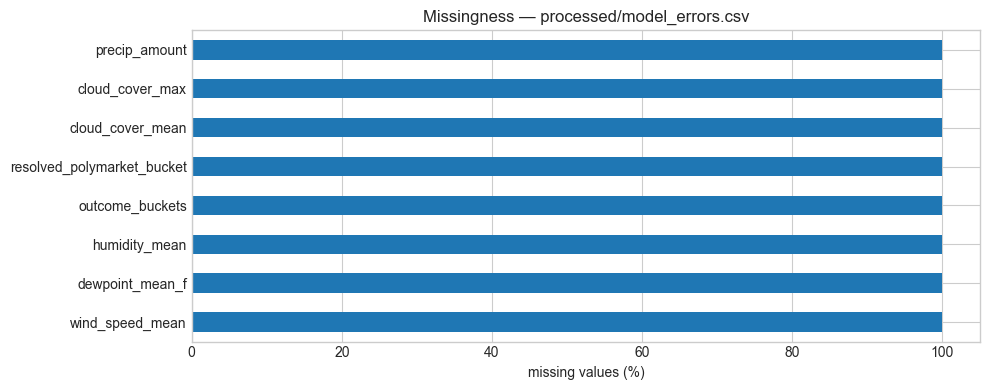

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
forecast_horizon_hours,29304.0,10.500410,8.874756,0.000000e+00,0.000000,0.000000,0.000000,12.000000,24.000000,24.000000,24.000000,24.00000
forecast_high_f,29304.0,75.492673,16.177001,2.146998e+01,38.516521,46.795991,63.374031,79.141993,88.285969,97.303987,102.955473,109.09402
actual_high_f,29304.0,75.896396,16.216082,2.100000e+01,38.000000,47.000000,64.000000,79.000000,89.000000,98.000000,104.000000,122.00000
error_f,29304.0,0.403724,4.255363,-3.952797e+01,-16.244371,-7.103387,-0.726002,0.992015,2.418521,5.230022,9.843808,46.07000
abs_error_f,29304.0,2.793992,3.234881,1.098633e-05,0.032105,0.172004,0.898040,1.896013,3.393987,8.866503,16.673970,46.07000
squared_error_f,29304.0,18.270488,60.974201,1.206994e-10,0.001031,0.029586,0.806475,3.594866,11.519147,78.614894,278.021275,2122.44490
month,29304.0,6.212667,3.555147,1.000000e+00,1.000000,1.000000,3.000000,6.000000,9.000000,12.000000,12.000000,12.00000
cloud_cover_mean,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cloud_cover_max,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precip_amount,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



event_id


,rows
event_id,
station-calendar-kmia,6076
station-calendar-kdal,5983
station-calendar-ksea,5839
station-calendar-kaus,5807
station-calendar-katl,5599



polymarket_city


,rows
polymarket_city,
KMIA,6076
KDAL,5983
KSEA,5839
KAUS,5807
KATL,5599


...

,rows
model,
nbm,29304



season


,rows
season,
winter,8124
spring,8012
fall,6952
summer,6216



day_of_week


,rows
day_of_week,
Monday,4220
Tuesday,4196
Friday,4192
Sunday,4180
Saturday,4176
Wednesday,4172
Thursday,4168


In [9]:
missing = active.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0].head(40)
if not missing.empty:
    ax = missing.sort_values().plot.barh(figsize=(10, max(4, len(missing) * 0.22)),
                                        title=f"Missingness — {ACTIVE_TABLE}")
    ax.set_xlabel("missing values (%)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in loaded rows.")

numeric = active.select_dtypes(include=np.number)
if not numeric.empty:
    display(numeric.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

categorical = active.select_dtypes(include=["object", "string", "category", "bool"])
low_cardinality = [c for c in categorical if active[c].nunique(dropna=True) <= 30]
for column in low_cardinality[:12]:
    print(f"\n{column}")
    display(active[column].value_counts(dropna=False).head(20).to_frame("rows"))

In [10]:
date_columns = [c for c in active if any(token in c.lower() for token in ("date", "time", "issued", "as_of", "fetched"))]
date_coverage = []
for column in date_columns:
    parsed = pd.to_datetime(active[column], errors="coerce", utc=True)
    if parsed.notna().any():
        date_coverage.append({"column": column, "parsed_rows": parsed.notna().sum(),
                              "first": parsed.min(), "last": parsed.max()})
display(pd.DataFrame(date_coverage))

dimension_columns = [c for c in ["station_code", "station_id", "provider", "model", "source",
                                  "settlement_source", "data_source", "quality_flag"] if c in active]
for column in dimension_columns:
    display(active[column].value_counts(dropna=False).head(30).rename("rows").to_frame())

,column,parsed_rows,first,last
0,issue_time_utc,29304,2021-12-31 00:00:00+00:00,2026-05-18 12:00:00+00:00
1,issue_time_local,29304,2021-12-31 00:00:00+00:00,2026-05-18 12:00:00+00:00
2,target_date_local,29304,2022-01-01 00:00:00+00:00,2026-05-18 00:00:00+00:00


,rows
station_code,
KMIA,6076
KDAL,5983
KSEA,5839
KAUS,5807
KATL,5599


,rows
provider,
nws,29304


,rows
model,
nbm,29304


## 6. Domain-specific weather and forecast checks

These cells use the consolidated model-error, actual-high, settlement,
and calibration tables when available. They skip cleanly on a partial pull.

,station_code,provider,model,rows,mae_f,median_ae_f,bias_f,p95_ae_f
3,KMIA,nws,nbm,6076,2.024924,1.572026,0.976590,5.392508
4,KSEA,nws,nbm,5839,2.457555,1.764031,0.725534,7.358010
2,KDAL,nws,nbm,5983,2.739301,2.058007,0.740071,7.665403
0,KATL,nws,nbm,5599,2.901339,2.019978,0.838428,9.061008
1,KAUS,nws,nbm,5807,3.889822,2.277996,-1.284938,15.074595


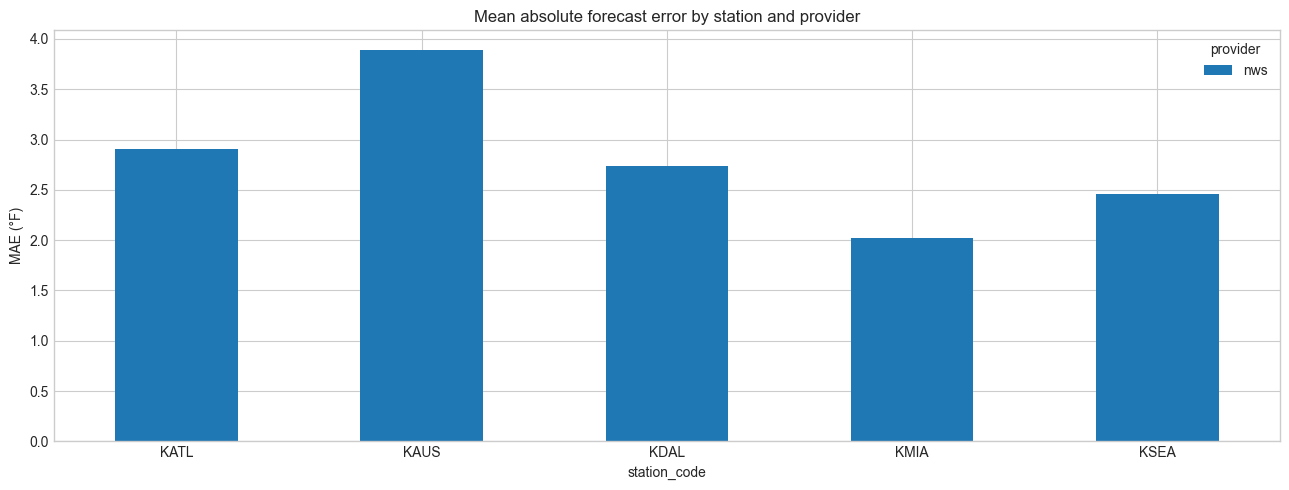

provider,nws
horizon_bin,
"(-inf, 6.0]",2.719295
"(6.0, 12.0]",2.824140
"(12.0, 24.0]",2.913210


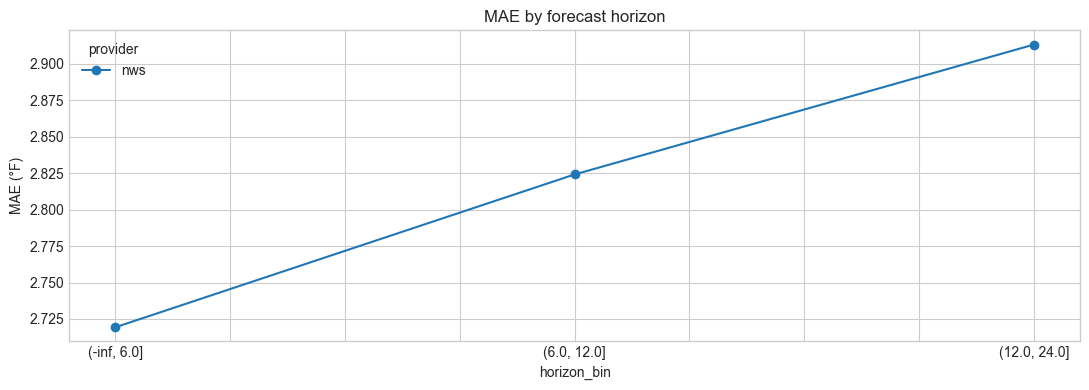

In [11]:
errors = tables.get("processed/model_errors.csv")
if errors is not None and {"abs_error_f", "error_f"}.issubset(errors):
    dims = [c for c in ["station_code", "provider", "model"] if c in errors]
    error_summary = (errors.groupby(dims, dropna=False)
                     .agg(rows=("abs_error_f", "size"), mae_f=("abs_error_f", "mean"),
                          median_ae_f=("abs_error_f", "median"), bias_f=("error_f", "mean"),
                          p95_ae_f=("abs_error_f", lambda s: s.quantile(.95)))
                     .reset_index().sort_values("mae_f"))
    display(error_summary)

    if "station_code" in errors and "provider" in errors:
        pivot = errors.pivot_table(index="station_code", columns="provider", values="abs_error_f", aggfunc="mean")
        pivot.plot.bar(figsize=(13, 5), title="Mean absolute forecast error by station and provider")
        plt.ylabel("MAE (°F)")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    if "forecast_horizon_hours" in errors:
        horizon = (errors.assign(horizon_bin=pd.cut(errors["forecast_horizon_hours"],
                                                    [-np.inf, 6, 12, 24, 48, 72, np.inf]))
                   .groupby(["horizon_bin", "provider"], observed=True)["abs_error_f"].mean().unstack())
        display(horizon)
        horizon.plot(marker="o", figsize=(11, 4), title="MAE by forecast horizon")
        plt.ylabel("MAE (°F)")
        plt.tight_layout()
        plt.show()
else:
    print("processed/model_errors.csv is unavailable or lacks error columns.")

In [12]:
actuals = tables.get("processed/actual_highs.csv")
settlements = tables.get("processed/settlement_actual_highs.csv")
if actuals is not None and settlements is not None:
    left = actuals.rename(columns={"station_code": "station", "date_local": "date"}).copy()
    right = settlements.rename(columns={"station_id": "station", "contract_date": "date"}).copy()
    left["date"] = pd.to_datetime(left["date"], errors="coerce")
    right["date"] = pd.to_datetime(right["date"], errors="coerce")
    comparison = left.merge(right, on=["station", "date"], how="inner", suffixes=("_actual", "_settlement"))
    if not comparison.empty and {"actual_high_f", "settlement_high_f"}.issubset(comparison):
        comparison["settlement_minus_actual_f"] = comparison["settlement_high_f"] - comparison["actual_high_f"]
        settlement_summary = (comparison.groupby("station")
                              .agg(overlap_days=("date", "size"), mean_difference_f=("settlement_minus_actual_f", "mean"),
                                   mae_difference_f=("settlement_minus_actual_f", lambda s: s.abs().mean()),
                                   max_abs_difference_f=("settlement_minus_actual_f", lambda s: s.abs().max()))
                              .sort_values("mae_difference_f", ascending=False))
        display(settlement_summary)
        display(comparison.loc[comparison["settlement_minus_actual_f"].abs() >= 2]
                .sort_values("settlement_minus_actual_f", key=lambda s: s.abs(), ascending=False).head(50))

,overlap_days,mean_difference_f,mae_difference_f,max_abs_difference_f
station,,,,
KLAX,1998,-1.194691,1.211751,46.0
KMIA,1998,-1.162168,1.183442,14.0
KSEA,1998,-1.093899,1.106643,45.0
KHOU,1998,-0.937048,1.052510,86.0
KATL,1998,-0.913889,0.950416,14.0
KDAL,1998,-0.856878,0.877861,22.0
KLGA,1998,-0.621726,0.675414,12.0
KAUS,1998,-0.637782,0.661164,19.0
KORD,1998,-0.535675,0.590968,14.0


,station,station_name,airport_name,date,actual_high_f,actual_high_time_local,actual_high_time_utc,actual_low_f,source,data_quality_flag,raw_observation_count,settlement_high_f,settlement_source,source_url,quality_flag,raw_value,notes,fetched_at_utc,settlement_minus_actual_f
7226,KHOU,Houston/Hobby Arpt,Houston/Hobby Arpt,2024-05-17,74.0,2024-05-17T12:11:00-05:00,2024-05-17T17:11:00+00:00,69.0,iem_asos_1min,ok,1440.0,160.0,wunderground_station_history,https://api.weather.com/v1/location/KHOU:9:US/observations/historical.json?units=e&startDate=20240517&endDate=20240517,ok,160.0,observation_count=40; timezone=America/Chicago,2026-07-08T04:45:46.632605+00:00,86.0
7468,KHOU,Houston/Hobby Arpt,Houston/Hobby Arpt,2025-01-14,99.0,2025-01-14T14:28:00-06:00,2025-01-14T20:28:00+00:00,-1.0,iem_asos_1min,ok,1260.0,53.0,wunderground_station_history,https://api.weather.com/v1/location/KHOU:9:US/observations/historical.json?units=e&startDate=20250114&endDate=20250114,ok,53.0,observation_count=24; timezone=America/Chicago,2026-07-08T04:46:00.901526+00:00,-46.0
9482,KLAX,Los Angeles Intl,Los Angeles Intl,2025-01-30,103.0,2025-01-30T06:06:00-08:00,2025-01-30T14:06:00+00:00,50.0,iem_asos_1min,ok,1438.0,57.0,wunderground_station_history,https://api.weather.com/v1/location/KLAX:9:US/observations/historical.json?units=e&startDate=20250130&endDate=20250130,ok,57.0,observation_count=26; timezone=America/Los_Angeles,2026-07-08T04:48:50.806453+00:00,-46.0
17031,KSEA,Seattle-Tacoma Intl,Seattle-Tacoma Intl,2023-11-14,94.0,2023-11-14T15:53:00-08:00,2023-11-14T23:53:00+00:00,34.0,iem_asos_1min,ok,1263.0,49.0,wunderground_station_history,https://api.weather.com/v1/location/KSEA:9:US/observations/historical.json?units=e&startDate=20231114&endDate=20231114,ok,49.0,observation_count=35; timezone=America/Los_Angeles,2026-07-08T05:01:41.667841+00:00,-45.0
9489,KLAX,Los Angeles Intl,Los Angeles Intl,2025-02-06,98.0,2025-02-06T07:57:00-08:00,2025-02-06T15:57:00+00:00,-1.0,iem_asos_1min,ok,1270.0,61.0,wunderground_station_history,https://api.weather.com/v1/location/KLAX:9:US/observations/historical.json?units=e&startDate=20250206&endDate=20250206,ok,61.0,observation_count=42; timezone=America/Los_Angeles,2026-07-08T04:48:52.713047+00:00,-37.0
16395,KSEA,Seattle-Tacoma Intl,Seattle-Tacoma Intl,2022-02-16,75.0,2022-02-16T11:08:00-08:00,2022-02-16T19:08:00+00:00,38.0,iem_asos_1min,ok,1429.0,51.0,wunderground_station_history,https://api.weather.com/v1/location/KSEA:9:US/observations/historical.json?units=e&startDate=20220216&endDate=20220216,ok,51.0,observation_count=32; timezone=America/Los_Angeles,2026-07-08T04:59:53.594449+00:00,-24.0
5424,KDAL,Dallas/Love Fld,Dallas/Love Fld,2024-11-29,76.0,2024-11-29T20:13:00-06:00,2024-11-30T02:13:00+00:00,0.0,iem_asos_1min,ok,1438.0,54.0,wunderground_station_history,https://api.weather.com/v1/location/KDAL:9:US/observations/historical.json?units=e&startDate=20241129&endDate=20241129,ok,54.0,observation_count=24; timezone=America/Chicago,2026-07-06T14:04:39.247874+00:00,-22.0
2760,KAUS,Austin/Bergstrom Intl,Austin/Bergstrom Intl,2023-02-02,60.0,2023-02-02T22:48:00-06:00,2023-02-03T04:48:00+00:00,32.0,iem_asos_1min,ok,1440.0,41.0,wunderground_station_history,https://api.weather.com/v1/location/KAUS:9:US/observations/historical.json?units=e&startDate=20230202&endDate=20230202,ok,41.0,observation_count=41; timezone=America/Chicago,2026-07-08T04:42:20.729839+00:00,-19.0
7486,KHOU,Houston/Hobby Arpt,Houston/Hobby Arpt,2025-02-01,91.0,2025-02-01T09:21:00-06:00,2025-02-01T15:21:00+00:00,-1.0,iem_asos_1min,ok,1383.0,73.0,wunderground_station_history,https://api.weather.com/v1/location/KHOU:9:US/observations/historical.json?units=e&startDate=20250201&endDate=20250201,ok,73.0,observation_count=23; timezone=America/Chicago,2026-07-08T04:46:02.565257+00:00,-18.0
16605,KSEA,Seattle-Tacoma Intl,Seattle-Tacoma Intl,2022-09-14,87.0,2022-09-14T10:16:00-07:00,2022-09-14T17:16:00+00:00,58.0,iem_asos_1min,ok,1432.0,70.0,wunderground_station_history,

,station_id,provider,timing_mode,data_source,rows,first_date,last_date,target_missing_pct
0,KATL,gfs,same_day_11am,mostlyright.weather.forecast_nwp,1898,2021-02-26,2026-05-27,0.0
1,KATL,hrrr,same_day_11am,mostlyright.weather.forecast_nwp,1884,2021-01-01,2026-05-27,0.0
2,KAUS,gfs,same_day_11am,mostlyright.weather.forecast_nwp,1896,2021-02-26,2026-05-27,0.0
3,KAUS,hrrr,same_day_11am,mostlyright.weather.forecast_nwp,1883,2021-01-01,2026-05-27,0.0
4,KDAL,gfs,same_day_11am,mostlyright.weather.forecast_nwp,1896,2021-02-26,2026-05-27,0.0
5,KDAL,hrrr,same_day_11am,mostlyright.weather.forecast_nwp,1883,2021-01-01,2026-05-27,0.0
6,KHOU,gfs,same_day_11am,mostlyright.weather.forecast_nwp,1896,2021-02-26,2026-05-27,0.0
7,KHOU,hrrr,same_day_11am,mostlyright.weather.forecast_nwp,1883,2021-01-01,2026-05-27,0.0
8,KLAX,gfs,same_day_11am,mostlyright.weather.forecast_nwp,1902,2021-02-26,2026-05-27,0.0
9,KLAX,hrrr,same_day_11am,mostlyright.weather.forecast_nwp,1880,2021-01-01,2026-05-27,0.0


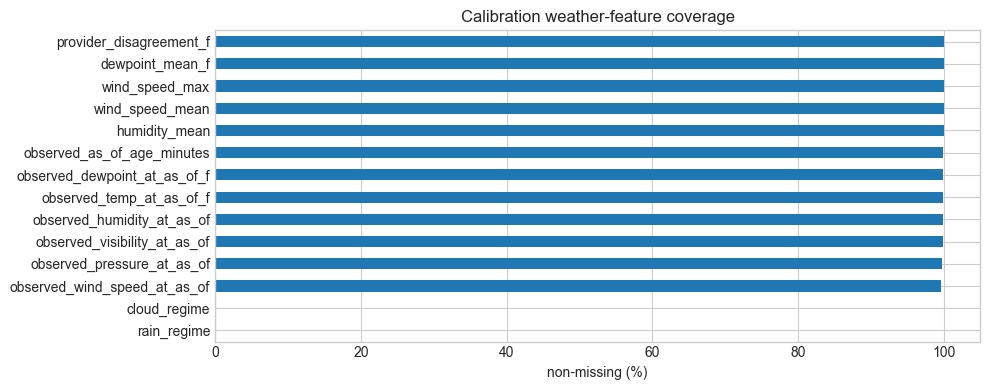

In [13]:
samples = tables.get("calibration/calibration_samples.csv")
if samples is not None:
    coverage_dims = [c for c in ["station_id", "provider", "timing_mode", "data_source"] if c in samples]
    calibration_coverage = (samples.groupby(coverage_dims, dropna=False)
                            .agg(rows=(coverage_dims[0], "size"),
                                 first_date=("contract_date", "min"), last_date=("contract_date", "max"),
                                 target_missing_pct=("actual_high_f", lambda s: s.isna().mean() * 100))
                            .reset_index())
    display(calibration_coverage)

    weather_features = [c for c in samples if any(token in c.lower() for token in
                        ["dewpoint", "humidity", "wind", "observed_", "disagreement", "cloud", "rain"])]
    if weather_features:
        feature_coverage = samples[weather_features].notna().mean().mul(100).sort_values()
        feature_coverage.plot.barh(figsize=(10, max(4, len(feature_coverage) * .23)),
                                   title="Calibration weather-feature coverage")
        plt.xlabel("non-missing (%)")
        plt.tight_layout()
        plt.show()

## 7. Model and database artifact catalog

Binary model files are intentionally not deserialized during EDA. SQLite
files are inspected only for table names and sizes, avoiding mutation of
active Optuna studies.

In [14]:
binary_artifacts = files[files["extension"].isin([".joblib", ".pkl", ".pickle", ".bin", ".model"])]
display(binary_artifacts.drop(columns="path").sort_values("size_bytes", ascending=False))

sqlite_rows = []
for row in files.loc[files["extension"] == ".sqlite3"].itertuples(index=False):
    try:
        uri = f"file:{row.path.as_posix()}?mode=ro"
        with sqlite3.connect(uri, uri=True) as conn:
            names = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"].tolist()
        sqlite_rows.append({"relative_path": row.relative_path, "size_mb": row.size_mb,
                            "tables": ", ".join(names), "status": "ok"})
    except Exception as exc:
        sqlite_rows.append({"relative_path": row.relative_path, "size_mb": row.size_mb,
                            "tables": "", "status": f"{type(exc).__name__}: {exc}"})
sqlite_catalog = pd.DataFrame(sqlite_rows)
display(sqlite_catalog)

,relative_path,logical_family,top_level,extension,size_bytes,size_mb,modified_utc,name,station_hint,date_hint
963,calibration/station_stacking_v10/model_weights/KATL_station_high_regressor_v10_catboost_huber.joblib,calibration/station_stacking_v10,calibration,.joblib,NaN,NaN,NaT,KATL_station_high_regressor_v10_catboost_huber.joblib,KATL,NaT
965,calibration/station_stacking_v10/model_weights/KAUS_station_high_regressor_v10_catboost_huber.joblib,calibration/station_stacking_v10,calibration,.joblib,NaN,NaN,NaT,KAUS_station_high_regressor_v10_catboost_huber.joblib,KAUS,NaT
1084,calibration/station_stacking_v11/model_weights/KATL_station_high_regressor_v11_huber_ridge_stack.joblib,calibration/station_stacking_v11,calibration,.joblib,NaN,NaN,NaT,KATL_station_high_regressor_v11_huber_ridge_stack.joblib,KATL,NaT
1086,calibration/station_stacking_v11/model_weights/KAUS_station_high_regressor_v11_huber_ridge_stack.joblib,calibration/station_stacking_v11,calibration,.joblib,NaN,NaN,NaT,KAUS_station_high_regressor_v11_huber_ridge_stack.joblib,KAUS,NaT
1088,calibration/station_stacking_v11/model_weights/KDAL_station_high_regressor_v11_huber_ridge_stack.joblib,calibration/station_stacking_v11,calibration,.joblib,NaN,NaN,NaT,KDAL_station_high_regressor_v11_huber_ridge_stack.joblib,KDAL,NaT
...,...,...,...,...,...,...,...,...,...,...
2571,calibration/station_stacking_v9/model_weights/KATL_station_high_regressor_v9_remaining_warmup.joblib,calibration/station_stacking_v9,calibration,.joblib,NaN,NaN,NaT,KATL_station_high_regressor_v9_remaining_warmup.joblib,KATL,NaT
2573,calibration/station_stacking_v9/model_weights/KAUS_station_high_regressor_v9_remaining_warmup.joblib,calibration/station_stacking_v9,calibration,.joblib,NaN,NaN,NaT,KAUS_station_high_regressor_v9_remaining_warmup.joblib,KAUS,NaT
2575,calibration/station_stacking_v9/model_weights/KDAL_station_high_regressor_v9_remaining_warmup.joblib,calibration/station_stacking_v9,calibration,.joblib,NaN,NaN,NaT,KDAL_station_high_regressor_v9_remaining_warmup.joblib,KDAL,NaT
2577,calibration/station_stacking_v9/model_weights/KLAX_station_high_regressor_v9_remaining_warmup.joblib,calibration/station_stacking_v9,calibration,.joblib,NaN,NaN,NaT,KLAX_station_high_regressor_v9_remaining_warmup.joblib,KLAX,NaT


,relative_path,size_mb,tables,status
0,calibration/station_stacking_v10/KATL_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
1,calibration/station_stacking_v10/KAUS_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
2,calibration/station_stacking_v10/KDAL_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
3,calibration/station_stacking_v10/KHOU_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
4,calibration/station_stacking_v11/KATL_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
...,...,...,...,...
86,calibration/station_stacking_v9/KDAL_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
87,calibration/station_stacking_v9/KLAX_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
88,calibration/station_stacking_v9/KMIA_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok
89,calibration/station_stacking_v9/KORD_optuna.sqlite3,NaN,"alembic_version, studies, study_directions, study_system_attributes, study_user_attributes, trial_heartbeats, trial_...",ok


## 8. Automated audit findings

This final table turns the exploration into a short review queue. It is
advisory: backups and experimental artifacts may be intentional.

In [15]:
findings = []
def add_finding(severity: str, area: str, finding: str, detail) -> None:
    findings.append({"severity": severity, "area": area, "finding": finding, "detail": detail})

if backup_mask.any():
    add_finding("info", "storage", "Backup/test-like artifacts present",
                f"{backup_mask.sum():,} files, {files.loc[backup_mask, 'size_mb'].sum():,.1f} MB")
if not duplicate_candidates.empty:
    add_finding("info", "storage", "Same-name/same-size duplicate candidates",
                f"{len(duplicate_candidates):,} candidate groups; hash to confirm")
failed_schemas = schema_catalog[schema_catalog["status"] != "ok"]
if not failed_schemas.empty:
    add_finding("warning", "schemas", "Representative files could not be read",
                f"{len(failed_schemas):,} logical families")
if "status" in table_catalog:
    failed_tables = table_catalog[table_catalog["status"] != "ok"]
    if not failed_tables.empty:
        add_finding("warning", "tables", "Consolidated tables could not be read", len(failed_tables))
high_missing = table_catalog.loc[pd.to_numeric(table_catalog.get("missing_pct"), errors="coerce") >= 50, "table"].tolist()
if high_missing:
    add_finding("review", "completeness", "Tables are at least 50% missing overall", ", ".join(high_missing))
stale_cutoff = pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=30)
newest_by_area = pd.to_datetime(by_area["newest_utc"], errors="coerce", utc=True)
stale_areas = by_area.loc[newest_by_area.notna() & (newest_by_area < stale_cutoff), "top_level"].tolist()
if stale_areas:
    add_finding("review", "freshness", "No artifact updated in the last 30 days", ", ".join(stale_areas))
if not findings:
    add_finding("ok", "overall", "No automatic warnings triggered", "Review domain plots for research conclusions")

audit_findings = pd.DataFrame(findings)
display(audit_findings)

# Optional exports (uncomment to persist compact audit outputs):
# out = ROOT / "outputs" / "eda"
# out.mkdir(parents=True, exist_ok=True)
# files.drop(columns="path").to_csv(out / "file_inventory.csv", index=False)
# table_catalog.to_csv(out / "table_catalog.csv", index=False)
# audit_findings.to_csv(out / "audit_findings.csv", index=False)

,severity,area,finding,detail
0,info,storage,Backup/test-like artifacts present,"146 files, 0.0 MB"
1,warning,schemas,Representative files could not be read,1 logical families
2,warning,tables,Consolidated tables could not be read,1
